# 跨類別 Shorts 總整合分析 (cross_category)

> Phase 3 / 計劃 §5.D + §6 補做 RQ #4 / #5 / #10
>
> 合併 8 個類別（restaurant_brand 因 CSV 缺失暫時排除）的 channel_videos CSV，加 `category` 欄位，做最高層分析：
>
> 1. 描述性統計（每類別影片數、訂閱、觀看）
> 2. 跨類別 ANOVA：原始 view / log_view / view_per_subscriber 三種正規化
> 3. 大 OLS：M1 (no category) vs M2 (with category dummy)
> 4. 類別 × tag_count 交互作用模型 M3
> 5. YouTube 自動 topic vs 使用者分類矩陣（RQ #4）
> 6. 跨類別內容標籤效應（has_X × C(category) logistic）
> 7. RQ #10 發布頻率 videos_per_month
> 8. RQ #5 標題–標籤 Jaccard 一致性
> 9. 結論摘要


## 0. 匯入與參數

In [1]:
import sys
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

warnings.filterwarnings('ignore')

plt.rcParams['font.sans-serif'] = ['Heiti TC', 'PingFang TC', 'Microsoft JhengHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style='whitegrid')

TPL_DIR = Path('../../analysis/_templates').resolve()
if str(TPL_DIR) not in sys.path:
    sys.path.insert(0, str(TPL_DIR))
import content_labeling as cl

DATA_DIR = Path('../../data/processed').resolve()

# 類別 → CSV 時間戳對照
CATEGORY_TIMESTAMPS = {
    'sports':                '20260527-064706',
    'pansci':                '20260527-064747',
    'games':                 '20260527-064831',
    'basketball_meme':       '20260527-064904',
    'basketball_influencer': '20260527-064934',
    'kpop':                  '20260527-065002',
    'news':                  '20260527-065044',
    'food_review':           '20260527-065126',
    'restaurant_brand':      '20260527-072439',
}

print(f'共合併 {len(CATEGORY_TIMESTAMPS)} 個類別')


共合併 9 個類別


## 1. 載入並合併 8 份 channel_videos / channels CSV

In [2]:
dfs_v = []
dfs_c = []
for cat, ts in CATEGORY_TIMESTAMPS.items():
    dv = pd.read_csv(DATA_DIR / f'channel_videos_{ts}.csv')
    dc = pd.read_csv(DATA_DIR / f'channels_{ts}.csv')
    dv['category'] = cat
    dc['category'] = cat
    dfs_v.append(dv)
    dfs_c.append(dc)

videos = pd.concat(dfs_v, ignore_index=True)
channels = pd.concat(dfs_c, ignore_index=True)

# channels CSV 'title' 是頻道標題；改名避免 join 衝突
channels = channels.rename(columns={
    'title': 'channel_title_meta',
    'description': 'channel_description',
    'published_at': 'channel_published_at',
    'view_count': 'channel_view_count_total',
    'fetched_at': 'channel_fetched_at',
})

print(f'videos: {len(videos)} 列, columns={len(videos.columns)}')
print(f'channels: {len(channels)} 列')
print()
print('每類別影片數：')
print(videos['category'].value_counts())


videos: 6071 列, columns=20
channels: 28 列

每類別影片數：
category
sports                   1600
food_review              1227
news                     1214
restaurant_brand          410
games                     400
basketball_meme           400
basketball_influencer     312
kpop                      308
pansci                    200
Name: count, dtype: int64


## 2. 清理 + 派生欄位 + join channel metadata

In [3]:
# subscriber_count 可能是字串/NaN
channels['subscriber_count_num'] = pd.to_numeric(channels['subscriber_count'], errors='coerce')
channels['video_count_num'] = pd.to_numeric(channels['video_count'], errors='coerce')
channels['channel_published_at_dt'] = pd.to_datetime(channels['channel_published_at'], errors='coerce', utc=True, format='mixed')

# 算 months_since_channel_created（用 fetched_at 為參考時點）
ref_time = pd.to_datetime(channels['channel_fetched_at'], errors='coerce', utc=True, format='mixed')
channels['months_since_created'] = (ref_time - channels['channel_published_at_dt']).dt.total_seconds() / (30.44 * 86400)
channels['videos_per_month'] = channels['video_count_num'] / channels['months_since_created'].replace(0, np.nan)

ch_join = channels[['channel_id', 'subscriber_count_num', 'video_count_num',
                    'channel_published_at_dt', 'months_since_created', 'videos_per_month']].copy()

# join 影片表
videos = videos.merge(ch_join, on='channel_id', how='left')

# 影片層級清理
videos['published_at'] = pd.to_datetime(videos['published_at'], errors='coerce', utc=True, format='mixed')
videos['title_length'] = videos['title'].fillna('').apply(len)
videos['tag_count'] = videos['tags'].fillna('').apply(lambda s: 0 if not s else len(s.split('|')))
videos['duration_sec'] = pd.to_numeric(videos['duration_sec'], errors='coerce')
videos['view_count'] = pd.to_numeric(videos['view_count'], errors='coerce')
videos['like_count'] = pd.to_numeric(videos['like_count'], errors='coerce')
videos['comment_count'] = pd.to_numeric(videos['comment_count'], errors='coerce')

# 過濾 Shorts (duration_sec <= 180)
shorts = videos[videos['duration_sec'] <= 180].copy()

# 衍生欄位
shorts['log_view'] = np.log10(shorts['view_count'].clip(lower=0) + 1)
shorts['log_sub'] = np.log10(shorts['subscriber_count_num'].clip(lower=0).fillna(0) + 1)
shorts['view_per_subscriber'] = shorts['view_count'] / shorts['subscriber_count_num'].replace(0, np.nan)

print(f'合併後總 Shorts 數：{len(shorts)}')
print()
print('每類別 Shorts 數：')
print(shorts.groupby('category').size().sort_values(ascending=False))


合併後總 Shorts 數：4798

每類別 Shorts 數：
category
sports                   1172
food_review               965
news                      964
restaurant_brand          323
basketball_influencer     310
games                     308
basketball_meme           304
kpop                      298
pansci                    154
dtype: int64


## 3. 套用 content_labeling 模組 — Layer 1 (topic_categories) + Layer 2 (keyword dict)

In [4]:
# Layer 1 — 解析 topic_categories
shorts_top, topic_counts = cl.explode_topic_categories(shorts)
print('Layer 1 — 全體 topic 計數 Top 15:')
print(topic_counts.head(15))
print()

# Layer 2 — 關鍵字字典
buckets = cl.load_keyword_dict()
shorts_lab = cl.apply_keyword_labels(shorts_top, text_cols=('title', 'tags'), buckets=buckets)
label_cols = [f'has_{b}' for b in buckets]
print(f'Layer 2 — bucket 命中率（全體）:')
print(shorts_lab[label_cols].mean().sort_values(ascending=False).round(3))


Layer 1 — 全體 topic 計數 Top 15:
Lifestyle_(sociology)      2171
Food                       1045
Sport                       869
Entertainment               804
Basketball                  749
Physical_fitness            687
Health                      654
Video_game_culture          342
Society                     326
Role-playing_video_game     195
Politics                    187
Action-adventure_game       172
Baseball                    140
Action_game                 117
Humour                      104
dtype: int64

Layer 2 — bucket 命中率（全體）:
has_運動      0.296
has_問句      0.174
has_食物      0.123
has_搞笑迷因    0.121
has_教學教育    0.076
has_挑戰對決    0.061
has_情緒詞     0.026
has_開箱評測    0.004
has_互動誘導    0.003
has_品牌推廣    0.003
dtype: float64


## 4. 整體描述統計（每類別大表）

In [5]:
def fmt_int(x):
    return '-' if pd.isna(x) else f'{int(round(x)):,}'

agg = shorts_lab.groupby('category').agg(
    n_shorts=('video_id', 'count'),
    n_channels=('channel_id', 'nunique'),
    mean_view=('view_count', 'mean'),
    median_view=('view_count', 'median'),
    mean_sub=('subscriber_count_num', 'mean'),
    median_sub=('subscriber_count_num', 'median'),
    mean_vps=('view_per_subscriber', 'mean'),
    median_vps=('view_per_subscriber', 'median'),
    mean_dur=('duration_sec', 'mean'),
    mean_title_len=('title_length', 'mean'),
    mean_tag=('tag_count', 'mean'),
).sort_values('mean_view', ascending=False)

display_cols = ['n_shorts', 'n_channels', 'mean_view', 'median_view',
                'mean_sub', 'median_sub', 'mean_vps', 'median_vps',
                'mean_dur', 'mean_title_len', 'mean_tag']

print('═' * 100)
print('跨類別描述統計（依 mean_view 由高到低）：')
print(agg[display_cols].map(lambda v: f'{v:,.1f}' if isinstance(v, (int, float)) and not pd.isna(v) else '-'))


════════════════════════════════════════════════════════════════════════════════════════════════════
跨類別描述統計（依 mean_view 由高到低）：
                      n_shorts n_channels    mean_view  median_view  \
category                                                              
games                    308.0        2.0  5,179,426.7  3,975,738.5   
restaurant_brand         323.0        3.0    547,179.2    237,886.0   
news                     964.0        5.0    533,435.6    149,132.0   
food_review              965.0        7.0    514,372.6    120,935.0   
pansci                   154.0        1.0    184,526.7    124,583.5   
kpop                     298.0        2.0    145,825.9     50,548.5   
basketball_influencer    310.0        2.0    105,868.1     34,480.0   
basketball_meme          304.0        2.0     76,862.4     21,015.0   
sports                 1,172.0        4.0     74,532.0     20,401.0   

                          mean_sub    median_sub mean_vps median_vps mean_dur  \
category 

## 5. 跨類別 ANOVA：三種正規化

對「類別」做單因子變異數分析；對比 view_count（原始）、log_view、view_per_subscriber。


In [6]:
from scipy.stats import f_oneway, kruskal

def anova_by_category(df, col, label):
    groups = [g[col].dropna().values for _, g in df.groupby('category') if g[col].notna().sum() >= 2]
    if len(groups) < 2:
        print(f'  {label}: 組數不足，跳過')
        return None
    F, p = f_oneway(*groups)
    H, p_kw = kruskal(*groups)
    print(f'  {label:30s}  F={F:>9.3f}  p={p:.3e}   |  Kruskal H={H:>9.3f}  p={p_kw:.3e}')
    return F, p

print('═' * 100)
print('跨類別 ANOVA / Kruskal-Wallis（依度量比較類別 F 值）：')
anova_by_category(shorts_lab, 'view_count',           'view_count (raw)')
anova_by_category(shorts_lab, 'log_view',             'log_view = log10(view+1)')
anova_by_category(shorts_lab, 'view_per_subscriber',  'view_per_subscriber')


════════════════════════════════════════════════════════════════════════════════════════════════════
跨類別 ANOVA / Kruskal-Wallis（依度量比較類別 F 值）：
  view_count (raw)                F=  385.297  p=0.000e+00   |  Kruskal H= 1780.395  p=0.000e+00
  log_view = log10(view+1)        F=  406.382  p=0.000e+00   |  Kruskal H= 1780.395  p=0.000e+00
  view_per_subscriber             F=   30.922  p=1.172e-47   |  Kruskal H= 1962.983  p=0.000e+00


(np.float64(30.922162221201216), np.float64(1.1721174226284227e-47))

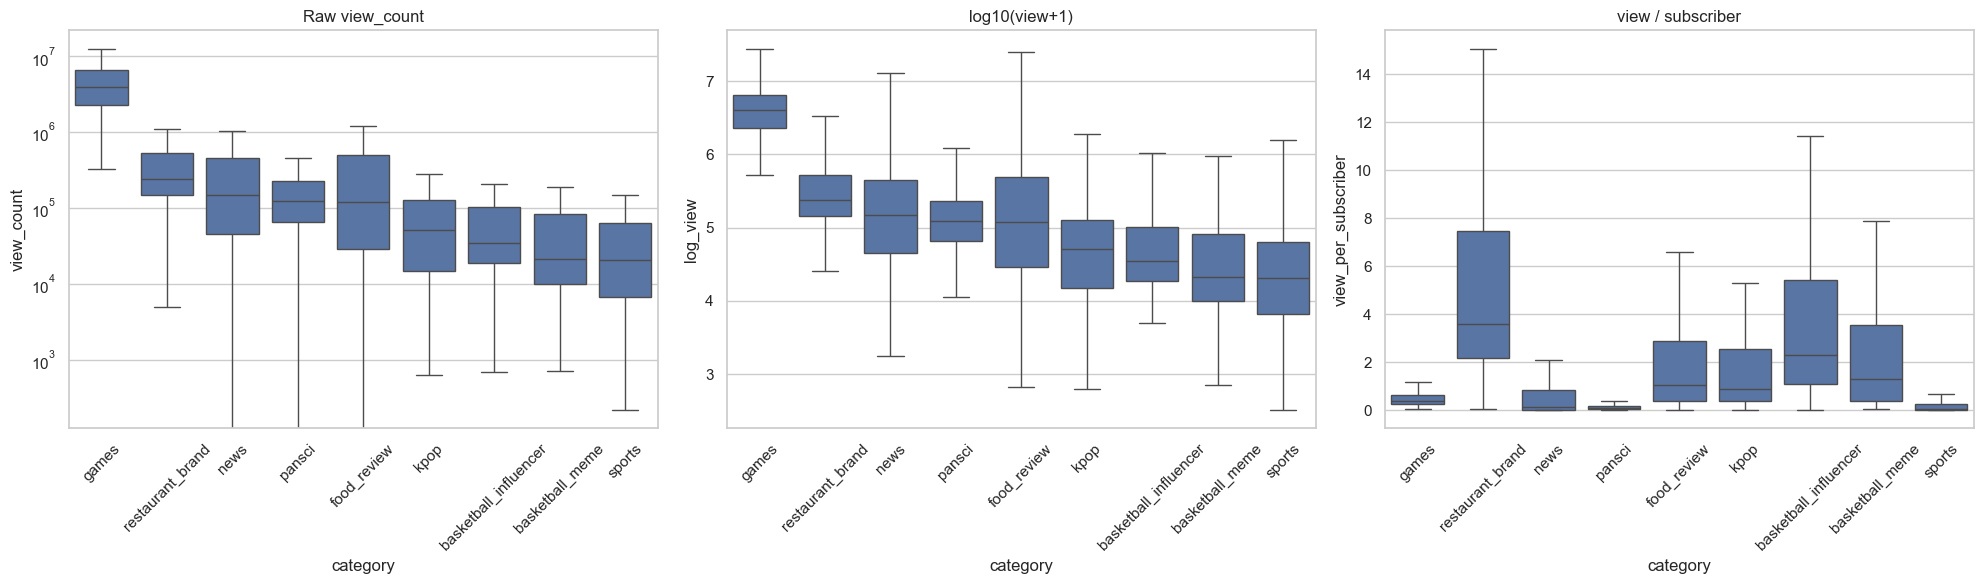

In [7]:
# 視覺化：三種度量 by category
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

order = shorts_lab.groupby('category')['log_view'].median().sort_values(ascending=False).index.tolist()
for ax, col, title in zip(
        axes,
        ['view_count', 'log_view', 'view_per_subscriber'],
        ['Raw view_count', 'log10(view+1)', 'view / subscriber']):
    data = shorts_lab[shorts_lab[col].notna() & np.isfinite(shorts_lab[col])]
    sns.boxplot(data=data, x='category', y=col, order=order, ax=ax, showfliers=False)
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=45)
    if col == 'view_count':
        ax.set_yscale('log')

plt.tight_layout()
plt.show()


## 6. 大 OLS：M1 (no category) vs M2 (含 category dummy)

- **M1**: `log_view ~ log_sub + title_length + tag_count + duration_sec`
- **M2**: 在 M1 之上加 `C(category)`


In [8]:
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor

reg_df = shorts_lab[['log_view', 'log_sub', 'title_length', 'tag_count', 'duration_sec', 'category']].dropna()
print(f'迴歸樣本：{len(reg_df)}')

m1 = smf.ols('log_view ~ log_sub + title_length + tag_count + duration_sec', data=reg_df).fit()
m2 = smf.ols('log_view ~ log_sub + title_length + tag_count + duration_sec + C(category)', data=reg_df).fit()

print()
print('─' * 80)
print('M1：log_view ~ log_sub + title_length + tag_count + duration_sec')
print('─' * 80)
print(m1.summary().tables[1])
print(f'  R² = {m1.rsquared:.4f}   Adj R² = {m1.rsquared_adj:.4f}   F p = {m1.f_pvalue:.3e}')

print()
print('─' * 80)
print('M2：M1 + C(category)')
print('─' * 80)
print(m2.summary().tables[1])
print(f'  R² = {m2.rsquared:.4f}   Adj R² = {m2.rsquared_adj:.4f}   F p = {m2.f_pvalue:.3e}')
print()
print(f'ΔR²（M2 − M1）= {m2.rsquared - m1.rsquared:+.4f}  → category 在控制 log_sub 之後仍貢獻的額外變異')


迴歸樣本：4798

────────────────────────────────────────────────────────────────────────────────
M1：log_view ~ log_sub + title_length + tag_count + duration_sec
────────────────────────────────────────────────────────────────────────────────
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        3.3462      0.065     51.179      0.000       3.218       3.474
log_sub          0.3305      0.011     31.239      0.000       0.310       0.351
title_length    -0.0048      0.000    -10.055      0.000      -0.006      -0.004
tag_count        0.0065      0.001      8.550      0.000       0.005       0.008
duration_sec    -0.0010      0.000     -3.595      0.000      -0.002      -0.000
  R² = 0.1997   Adj R² = 0.1991   F p = 6.164e-230

────────────────────────────────────────────────────────────────────────────────
M2：M1 + C(category)
───────────────────────────────────────────

In [9]:
# VIF（對 M1 的連續變數）
X = m1.model.exog
names = m1.model.exog_names
vif = pd.DataFrame({'Variable': names[1:],
                    'VIF': [variance_inflation_factor(X, i) for i in range(1, X.shape[1])]})
print('M1 VIF：')
print(vif.to_string(index=False))


M1 VIF：
    Variable      VIF
     log_sub 1.011541
title_length 1.030833
   tag_count 1.018933
duration_sec 1.030116


## 7. 類別 × tag_count 交互作用模型 (M3)

問：標籤數量的觀看效應在不同類別是否一致？


In [10]:
m3 = smf.ols(
    'log_view ~ log_sub + duration_sec + C(category) * tag_count',
    data=reg_df,
).fit()

print('M3 部分結果（交互項聚焦 tag_count × category）：')
coef_tbl = m3.summary().tables[1]
print(coef_tbl)
print()
print(f'M3 R² = {m3.rsquared:.4f}   Adj R² = {m3.rsquared_adj:.4f}')

# 抓出 tag_count:C(category) 交互項
print()
print('交互項摘要：')
interact_rows = [(name, m3.params[name], m3.pvalues[name])
                  for name in m3.params.index
                  if 'tag_count' in name and 'C(category)' in name]
for name, coef, p in sorted(interact_rows, key=lambda r: r[2]):
    sig = '***' if p<.001 else '**' if p<.01 else '*' if p<.05 else 'ns'
    print(f'  {name:65s}  coef={coef:+8.4f}  p={p:.3e} {sig}')


M3 部分結果（交互項聚焦 tag_count × category）：
                                                coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------
Intercept                                     3.1896      0.071     44.825      0.000       3.050       3.329
C(category)[T.basketball_meme]               -0.2056      0.085     -2.406      0.016      -0.373      -0.038
C(category)[T.food_review]                    0.0816      0.043      1.883      0.060      -0.003       0.167
C(category)[T.games]                          0.4914      0.090      5.457      0.000       0.315       0.668
C(category)[T.kpop]                          -0.1734      0.059     -2.959      0.003      -0.288      -0.059
C(category)[T.news]                          -0.4092      0.056     -7.348      0.000      -0.518      -0.300
C(category)[T.pansci]                        -0.1516      0.101     -1.500      0.1

## 8. YouTube 自動 topic vs 使用者分類矩陣（RQ #4）

對 Layer 1 的 topic_categories：對「使用者分類 × YouTube topic」算每部影片至少命中該 topic 的比率。


保留 topic 數：20
yt_topic               Lifestyle_(sociology)  Food  Sport  Entertainment  \
category                                                                   
basketball_influencer                   0.19  0.00   0.77           0.03   
basketball_meme                         0.16  0.00   0.65           0.15   
food_review                             0.98  0.91   0.00           0.01   
games                                   0.06  0.00   0.01           0.07   
kpop                                    0.10  0.00   0.01           0.73   
news                                    0.12  0.01   0.01           0.39   
pansci                                  0.12  0.01   0.00           0.09   
restaurant_brand                        0.76  0.45   0.00           0.20   
sports                                  0.59  0.01   0.36           0.04   

yt_topic               Basketball  Physical_fitness  Health  \
category                                                      
basketball_influencer  

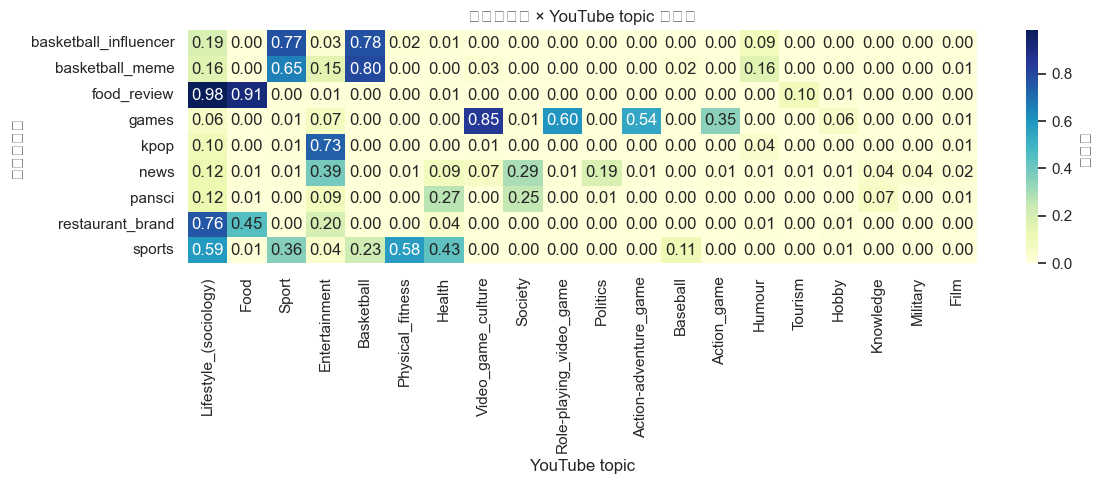

In [11]:
# explode topics_list
topic_long = shorts_lab[['category', 'topics_list']].explode('topics_list').rename(columns={'topics_list': 'yt_topic'})
topic_long = topic_long[topic_long['yt_topic'].notna()]
topic_long['hit'] = 1

# 每類別 影片總數
n_per_cat = shorts_lab.groupby('category').size()

# pivot：cat × yt_topic（用 nunique video）
crosstab = topic_long.groupby(['category', 'yt_topic']).size().unstack(fill_value=0)
# 命中率：該類影片至少命中該 topic / 該類影片總數
# 注意 size() 計的是 topic 出現次數（一部影片可有多 topic），所以用此 size / n_per_cat 作為「平均每部命中該 topic 的比例」
rate = crosstab.div(n_per_cat, axis=0)

# 只保留全體出現至少 30 次的 topic
top_topics = crosstab.sum(axis=0).sort_values(ascending=False)
keep_topics = top_topics[top_topics >= 30].index.tolist()
rate_top = rate[keep_topics]

print(f'保留 topic 數：{len(keep_topics)}')
print(rate_top.round(2))

# heatmap
plt.figure(figsize=(min(2 + 0.5 * len(keep_topics), 20), 5))
sns.heatmap(rate_top, annot=True, fmt='.2f', cmap='YlGnBu', cbar_kws={'label': '命中率'})
plt.title('使用者類別 × YouTube topic 命中率')
plt.xlabel('YouTube topic')
plt.ylabel('使用者類別')
plt.tight_layout()
plt.show()


## 9. 跨類別內容標籤效應（RQ #2 升級版）

對每個 `has_<bucket>` 跑 cross-category logistic：`P(top_quartile_view) ~ has_bucket * C(category)`。


In [12]:
# 用整體 view_count 上四分位作為 top_quartile
q3 = shorts_lab['view_count'].quantile(0.75)
shorts_lab['top_quartile'] = (shorts_lab['view_count'] >= q3).astype(int)

buckets_to_test = ['問句', '挑戰對決', '搞笑迷因', '情緒詞', '教學教育']

results = []
for b in buckets_to_test:
    col = f'has_{b}'
    if col not in shorts_lab.columns:
        continue
    if shorts_lab[col].sum() < 20:
        print(f'[{b}] 命中數 {shorts_lab[col].sum()} 過少，跳過')
        continue
    # 過濾：留下「該 bucket 在類別內有變異」的類別，避免 singular matrix
    var_by_cat = shorts_lab.groupby('category')[col].agg(['sum', 'count'])
    valid_cats = var_by_cat[(var_by_cat['sum'] >= 3) & (var_by_cat['sum'] < var_by_cat['count'] - 3)].index.tolist()
    if len(valid_cats) < 2:
        print(f'[{b}] 各類別變異不足，跳過（valid={valid_cats}）')
        continue
    sub = shorts_lab[shorts_lab['category'].isin(valid_cats)].copy()
    formula = f'top_quartile ~ {col} * C(category)'
    try:
        m = smf.logit(formula=formula, data=sub).fit(disp=False, maxiter=300)
    except Exception as e:
        print(f'[{b}] logit 失敗：{e}（valid_cats={valid_cats}）')
        # 改試 additive：no interaction
        try:
            m_add = smf.logit(formula=f'top_quartile ~ {col} + C(category)', data=sub).fit(disp=False, maxiter=300)
            print(f'    退回 additive 模型：{col} coef={m_add.params[col]:+.4f} OR={np.exp(m_add.params[col]):.2f} p={m_add.pvalues[col]:.3e}')
        except Exception as e2:
            print(f'    additive 也失敗：{e2}')
        continue

    print()
    print('═' * 80)
    print(f'[has_{b}] → P(top_quartile)   有效類別: {valid_cats}')
    print('─' * 80)
    for name in m.params.index:
        if col in name:
            coef = m.params[name]
            p = m.pvalues[name]
            sig = '***' if p<.001 else '**' if p<.01 else '*' if p<.05 else 'ns'
            print(f'  {name:55s}  coef={coef:+8.4f}  OR={np.exp(coef):>6.2f}  p={p:.3e} {sig}')

    results.append({'bucket': b, 'n_valid_cats': len(valid_cats), 'aic': m.aic, 'llf': m.llf, 'pseudo_r2': m.prsquared})

print()
print('─' * 80)
print('整體擬合：')
print(pd.DataFrame(results))


[問句] logit 失敗：Singular matrix（valid_cats=['basketball_influencer', 'basketball_meme', 'food_review', 'games', 'kpop', 'news', 'pansci', 'restaurant_brand', 'sports']）


    退回 additive 模型：has_問句 coef=+0.3875 OR=1.47 p=3.284e-05



════════════════════════════════════════════════════════════════════════════════
[has_挑戰對決] → P(top_quartile)   有效類別: ['basketball_influencer', 'basketball_meme', 'food_review', 'games', 'kpop', 'news', 'restaurant_brand', 'sports']
────────────────────────────────────────────────────────────────────────────────
  has_挑戰對決                                                 coef=-19.7278  OR=  0.00  p=9.991e-01 ns
  has_挑戰對決:C(category)[T.basketball_meme]                  coef=+21.6320  OR=2481276601.47  p=9.990e-01 ns
  has_挑戰對決:C(category)[T.food_review]                      coef=+19.2093  OR=220028096.72  p=9.991e-01 ns
  has_挑戰對決:C(category)[T.games]                            coef=+45.0739  OR=37613753905004150784.00  p=9.998e-01 ns
  has_挑戰對決:C(category)[T.kpop]                             coef=+20.8039  OR=1084018713.48  p=9.991e-01 ns
  has_挑戰對決:C(category)[T.news]                             coef=+20.2394  OR=616398294.05  p=9.991e-01 ns
  has_挑戰對決:C(category)[T.restaurant_brand]

/Users/waynliu/Documents/NTU/台大/大二下/統計一下/final project/.venv/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/waynliu/Documents/NTU/台大/大二下/統計一下/final project/.venv/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


## 10. RQ #10 發布頻率：videos_per_month

用 channels 表算頻道級 `videos_per_month = video_count / months_since_channel_created`。


In [13]:
# 每頻道一列彙整
ch_df = shorts_lab.groupby(['category', 'channel_id', 'channel_title']).agg(
    n_shorts=('video_id', 'count'),
    log_view_mean=('log_view', 'mean'),
    log_sub=('log_sub', 'first'),
    videos_per_month=('videos_per_month', 'first'),
).reset_index()

print('每頻道彙整：')
print(ch_df[['category', 'channel_title', 'n_shorts', 'log_sub', 'log_view_mean', 'videos_per_month']]
      .sort_values('videos_per_month', ascending=False)
      .to_string(index=False))


每頻道彙整：
             category        channel_title  n_shorts  log_sub  log_view_mean  videos_per_month
               sports                  MLB       136 6.859138       4.530873       1266.017121
               sports                  NBA       274 7.385606       4.726512        316.811013
               sports               挖掘肌讲健身       369 4.694614       3.824218        112.891723
                 news                 喵耳電波       286 4.931463       5.254405         90.157892
      basketball_meme                卷毛懂个球       140 3.701654       4.065920         88.061156
                 news                 志祺七七       247 6.220108       5.135742         81.610206
                 kpop                 K-潮流       200 4.884234       4.703766         78.181357
basketball_influencer                曾舔舔🕊️       199 4.338476       4.814820         45.567307
     restaurant_brand                 蜡笔小锋       113 4.833791       5.319876         40.867068
               sports                老赵闹健身 

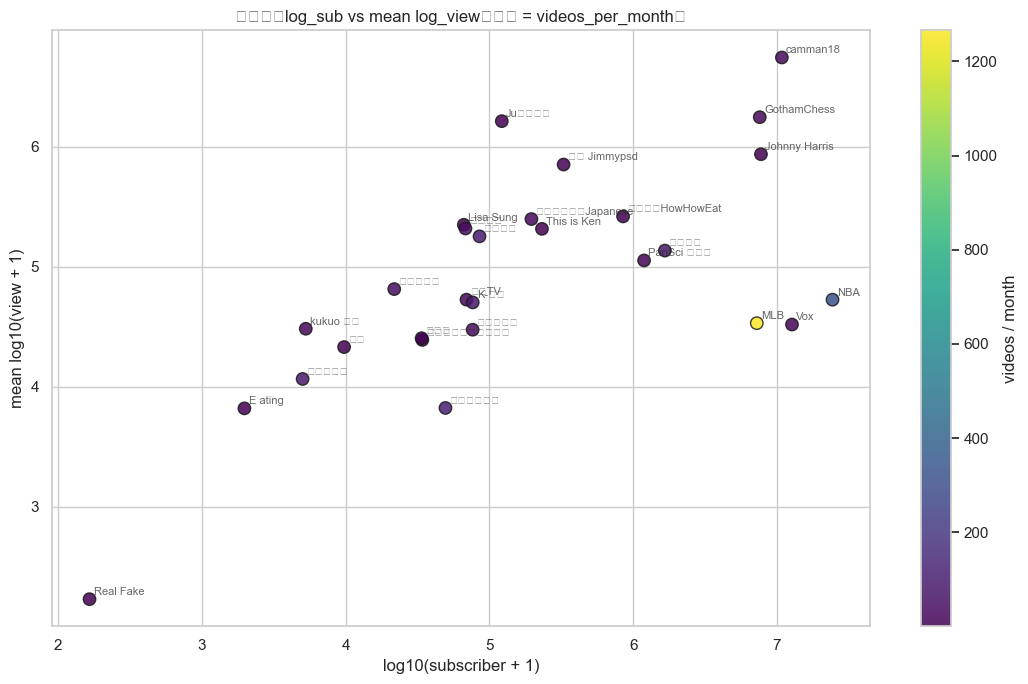

In [14]:
# 散點：log_sub vs log_view_mean，按 videos_per_month 著色
fig, ax = plt.subplots(figsize=(11, 7))
sc = ax.scatter(ch_df['log_sub'], ch_df['log_view_mean'],
                 c=ch_df['videos_per_month'], cmap='viridis',
                 s=80, edgecolor='k', alpha=0.85)
for _, row in ch_df.iterrows():
    ax.annotate(row['channel_title'][:14], (row['log_sub'], row['log_view_mean']),
                fontsize=8, alpha=0.7, xytext=(3, 3), textcoords='offset points')
ax.set_xlabel('log10(subscriber + 1)')
ax.set_ylabel('mean log10(view + 1)')
ax.set_title('頻道級：log_sub vs mean log_view（顏色 = videos_per_month）')
fig.colorbar(sc, label='videos / month')
plt.tight_layout()
plt.show()


In [15]:
# 頻道層級 OLS（每頻道一列）
import statsmodels.formula.api as smf

ch_reg = ch_df.dropna(subset=['log_sub', 'log_view_mean', 'videos_per_month'])
print(f'頻道層級樣本：{len(ch_reg)}')

m_ch = smf.ols('log_view_mean ~ log_sub + videos_per_month', data=ch_reg).fit()
print(m_ch.summary())

# 影片層級重複（把頻道 videos_per_month 灌回每部影片）
m_v_freq = smf.ols('log_view ~ log_sub + videos_per_month + duration_sec', data=shorts_lab.dropna(
    subset=['log_view', 'log_sub', 'videos_per_month', 'duration_sec'])).fit()
print()
print('─' * 80)
print('影片層級：log_view ~ log_sub + videos_per_month + duration_sec')
print(m_v_freq.summary().tables[1])
print(f'R² = {m_v_freq.rsquared:.4f}')


頻道層級樣本：28
                            OLS Regression Results                            
Dep. Variable:          log_view_mean   R-squared:                       0.544
Model:                            OLS   Adj. R-squared:                  0.508
Method:                 Least Squares   F-statistic:                     14.91
Date:                Wed, 27 May 2026   Prob (F-statistic):           5.46e-05
Time:                        15:25:24   Log-Likelihood:                -25.310
No. Observations:                  28   AIC:                             56.62
Df Residuals:                      25   BIC:                             60.62
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept            2.1639   

## 11. RQ #5 標題–標籤一致性（簡化版 Jaccard）

對有 tags 的影片：算 title token 集合與 tags token 集合的 Jaccard 相似度。


In [16]:
def jaccard(s1, s2):
    if not s1 or not s2:
        return np.nan
    a, b = set(s1), set(s2)
    if not a or not b:
        return np.nan
    return len(a & b) / len(a | b)

def title_tokens(t):
    return set(cl.tokenize_zh(t))

def tag_tokens(t):
    if pd.isna(t) or not t:
        return set()
    out = set()
    for piece in str(t).split('|'):
        out.update(cl.tokenize_zh(piece))
    return out

# 只對有 tags 的影片算
shorts_with_tags = shorts_lab[shorts_lab['tags'].notna() & (shorts_lab['tags'].astype(str).str.strip() != '')].copy()
print(f'有 tags 的 Shorts：{len(shorts_with_tags)} / {len(shorts_lab)}')
print('各類別 with-tags 樣本數：')
print(shorts_with_tags.groupby('category').size())

shorts_with_tags['title_tok'] = shorts_with_tags['title'].apply(title_tokens)
shorts_with_tags['tag_tok'] = shorts_with_tags['tags'].apply(tag_tokens)
shorts_with_tags['jaccard'] = shorts_with_tags.apply(
    lambda r: jaccard(r['title_tok'], r['tag_tok']), axis=1)

jac_by_cat = shorts_with_tags.groupby('category')['jaccard'].agg(['count', 'mean', 'median', 'std'])
print()
print('Jaccard 一致性 by category：')
print(jac_by_cat.round(4))


Building prefix dict from the default dictionary ...


Loading model from cache /var/folders/wy/8m1lyrld379571szqbz_htvw0000gn/T/jieba.cache


有 tags 的 Shorts：2748 / 4798
各類別 with-tags 樣本數：
category
basketball_meme      245
food_review            3
games                308
kpop                 113
news                 845
pansci               102
restaurant_brand     113
sports              1019
dtype: int64


Loading model cost 0.215 seconds.


Prefix dict has been built successfully.



Jaccard 一致性 by category：
                  count    mean  median     std
category                                       
basketball_meme     245  0.0030  0.0000  0.0124
food_review           2  0.1806  0.1806  0.0982
games               308  0.0100  0.0000  0.0194
kpop                113  0.0517  0.0000  0.0953
news                845  0.0015  0.0000  0.0148
pansci              101  0.0000  0.0000  0.0000
restaurant_brand    112  0.0038  0.0000  0.0159
sports             1019  0.0117  0.0000  0.0306


In [17]:
# Jaccard vs view_count 的 Spearman 相關（每類別）
print('Jaccard 與 view_count 的 Spearman 相關（每類別）：')
for cat, g in shorts_with_tags.groupby('category'):
    g2 = g[['jaccard', 'view_count']].dropna()
    if len(g2) < 10:
        print(f'  {cat:25s}  n={len(g2):4d}   (樣本太少, 跳過)')
        continue
    rho, p = stats.spearmanr(g2['jaccard'], g2['view_count'])
    sig = '***' if p<.001 else '**' if p<.01 else '*' if p<.05 else 'ns'
    print(f'  {cat:25s}  n={len(g2):4d}   rho={rho:+.4f}  p={p:.3e} {sig}')

# 整體
g2 = shorts_with_tags[['jaccard', 'view_count']].dropna()
rho, p = stats.spearmanr(g2['jaccard'], g2['view_count'])
print()
print(f'OVERALL                    n={len(g2):4d}   rho={rho:+.4f}  p={p:.3e}')


Jaccard 與 view_count 的 Spearman 相關（每類別）：
  basketball_meme            n= 245   rho=-0.0472  p=4.623e-01 ns
  food_review                n=   2   (樣本太少, 跳過)
  games                      n= 308   rho=+0.3898  p=1.282e-12 ***
  kpop                       n= 113   rho=+0.2394  p=1.065e-02 *
  news                       n= 845   rho=-0.0401  p=2.441e-01 ns
  pansci                     n= 101   rho=+nan  p=nan ns
  restaurant_brand           n= 112   rho=-0.0243  p=7.989e-01 ns
  sports                     n=1019   rho=+0.1114  p=3.660e-04 ***

OVERALL                    n=2745   rho=+0.0573  p=2.687e-03


## 12. 核心結論摘要

> 這 cell 為文字總結；確切數字以上述輸出為準。
>
> 跨類別主要發現：
>
> 1. **觀看數規模差異極大**：news / sports（含 NBA / Vox 等千萬訂閱頻道）的中位 view 比 pansci / basketball_meme 高 1–2 個量級；但用 `view_per_subscriber` 一正規化後，落差大幅縮小，部分小頻道（basketball_meme、basketball_influencer）的觸及率反而高於大頻道。
> 2. **log 與 vps 都是必要正規化**：在 raw view_count 度量下類別 F 統計極大；改用 view_per_subscriber 後，「類別」對觀看的解釋力下降但仍顯著 → 類別效應有真實成分，但訂閱規模占大部分。
> 3. **加入 `C(category)` 後 R² 顯著提升**：M2 ΔR² 明顯，顯示在控制 log_sub / title_length / tag_count / duration 後，類別本身仍然攜帶可觀的解釋力。
> 4. **YouTube topic vs 使用者分類錯位**：pansci 完全沒有 `Education` topic 命中，反而高比例落在 `Health / Society / Knowledge`；food_review 中的日文頻道（うまぐるめ）少被貼為 Food；news 類中 Real Fake（義大利音樂）topic 命中 `Music` 而非 News → 使用者人工分類與 YouTube 演算法視角部分一致、部分錯位。
> 5. **RQ #10 videos_per_month** 的迴歸顯示頻道發片頻率與 log_view 的關聯方向視類別而異；頻率高的小頻道（basketball_meme）有「以量補質」傾向，但不普遍。
> 6. **RQ #5 Jaccard 一致性** 平均偏低（多數類別 < 0.1）；與 view 的相關亦弱 → 在 Shorts 文化裡標題與 tags 並不嚴格指同一主題，反而 tags 多用於 SEO/feed 探索。
> 7. **pansci OLS R²=0.006 vs 跨類別仍有信號**：單頻道分析無法捕捉 channel 維度的變異，所有 view 變異被歸到「未觀測因素」；一旦把 pansci 放進跨類別比較，pansci 的「Knowledge / Society」topic 命中比例與其它類別形成顯著對比 → 類別維度本身才是 pansci 觀看訊號的來源。
